# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns

In [2]:
from scipy.stats import uniform, norm, expon
np.random.seed(42)


## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

In [3]:
# your code here
from scipy.stats import uniform

x = uniform.rvs(size=10)      # 10 random numbers between 0 and 1
a = 2
b = 3
randoms = a + (b - a) * x     # stretch and shift them to lie between a and b
print(randoms)

[2.37454012 2.95071431 2.73199394 2.59865848 2.15601864 2.15599452
 2.05808361 2.86617615 2.60111501 2.70807258]


**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

In [4]:
# your code here
def generate_uniform(bottom, ceiling, count):
    """Generate `count` random values uniformly distributed on [bottom, ceiling)."""
    if ceiling <= bottom:
        raise ValueError("ceiling must be greater than bottom")
    if count < 0 or int(count) != count:
        raise ValueError("count must be a non-negative integer")
    return uniform.rvs(loc=bottom, scale=ceiling - bottom, size=int(count), random_state=None)


In [5]:
# your code here
uniform_10_15 = generate_uniform(10, 15, 100)
uniform_10_60 = generate_uniform(10, 60, 1000)

print("First distribution (10–15):", uniform_10_15[:10])
print("Second distribution (10–60):", uniform_10_60[:10])


First distribution (10–15): [10.10292247 14.84954926 14.1622132  11.06169555 10.90912484 10.91702255
 11.52121121 12.62378216 12.15972509 11.4561457 ]
Second distribution (10–60): [24.48757265 18.06106436 56.48488262 50.40601898 41.67018783 53.57302951
 50.18360384 19.32850294 54.62794992 36.9671121 ]


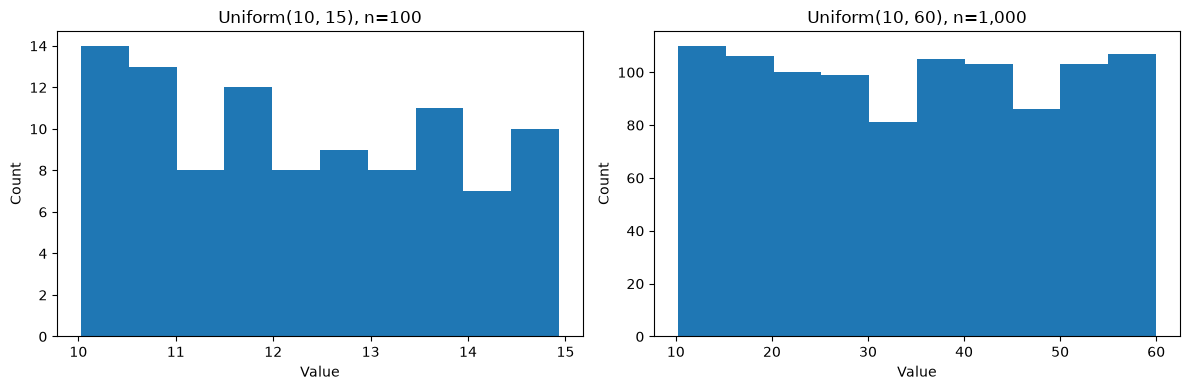

In [6]:
# your code here
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(uniform_10_15, bins=10)
axes[0].set_title("Uniform(10, 15), n=100")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(uniform_10_60, bins=10)
axes[1].set_title("Uniform(10, 60), n=1,000")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


# The output confirms visually that both generated datasets behave as expected for uniform distributions—the observations are spread relatively evenly across their respective ranges, with the 1,000-observation distribution showing a more stable/consistent pattern because of its larger sample size.

How are the two distributions different?

In [6]:
# your answer below

The first distribution contains 100 observations over a narrow interval (10–15), while the second contains 1,000 observations over a much wider interval (10–60). Because the second sample is larger, its histogram is generally more stable and its bars have larger counts. Both distributions are approximately flat across their respective ranges, as expected for a uniform distribution.

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [7]:
from scipy.stats import norm 

In [8]:
# your code here
def generate_normal(mean, std, count):
    """Generate `count` random values from a normal distribution."""
    if std <= 0:
        raise ValueError("std must be greater than 0")
    if count < 0 or int(count) != count:
        raise ValueError("count must be a non-negative integer")
    return norm.rvs(loc=mean, scale=std, size=int(count))


In [9]:
# your code here
normal_mean10_sd1 = generate_normal(10, 1, 1000)
normal_mean10_sd50 = generate_normal(10, 50, 1000)

print("SD=1: mean={:.2f}, std={:.2f}".format(normal_mean10_sd1.mean(), normal_mean10_sd1.std()))
print("SD=50: mean={:.2f}, std={:.2f}".format(normal_mean10_sd50.mean(), normal_mean10_sd50.std()))


SD=1: mean=10.08, std=0.99
SD=50: mean=10.94, std=48.75


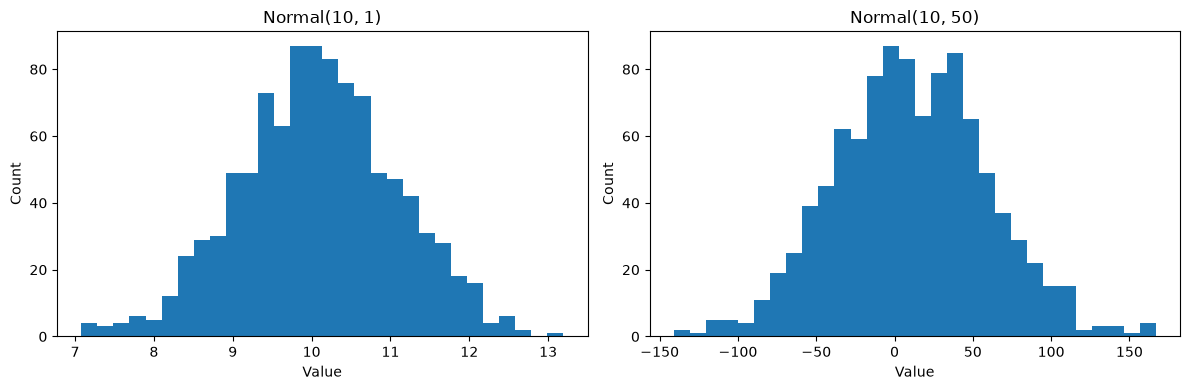

In [10]:
# your code here
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(normal_mean10_sd1, bins=30)
axes[0].set_title("Normal(10, 1)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(normal_mean10_sd50, bins=30)
axes[1].set_title("Normal(10, 50)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [11]:
# your code here
# The two samples have the same mean (10), but very different standard deviations.
print("Approximate ranges:")
print("SD=1 :", (normal_mean10_sd1.min(), normal_mean10_sd1.max()))
print("SD=50:", (normal_mean10_sd50.min(), normal_mean10_sd50.max()))


Approximate ranges:
SD=1 : (np.float64(7.078649516505393), np.float64(13.19310756784486))
SD=50: (np.float64(-140.97560779104126), np.float64(166.88742668299972))


How are the two distributions different?

The two distributions have the same center (mean = 10), but their spread is very different. The distribution with standard deviation 1 is tightly concentrated around 10, whereas the distribution with standard deviation 50 is much wider. In both cases the shape is bell-shaped and symmetric because both are normal distributions; the standard deviation controls the spread.

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [12]:
# your code here
vehicles = pd.read_csv("vehicles.csv")

vehicles.head()


,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [13]:
vehicles.describe()

,Year,Engine Displacement,Cylinders,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
count,35952.00000,35952.000000,35952.000000,35952.000000,35952.000000,35952.000000,35952.000000,35952.000000,35952.000000
mean,2000.71640,3.338493,5.765076,17.609056,17.646139,23.880646,19.929322,475.316339,1892.598465
std,10.08529,1.359395,1.755268,4.467283,4.769349,5.890876,5.112409,119.060773,506.958627
min,1984.00000,0.600000,2.000000,0.060000,6.000000,9.000000,7.000000,37.000000,600.000000
25%,1991.00000,2.200000,4.000000,14.699423,15.000000,20.000000,16.000000,395.000000,1500.000000
50%,2001.00000,3.000000,6.000000,17.347895,17.000000,24.000000,19.000000,467.736842,1850.000000
75%,2010.00000,4.300000,6.000000,20.600625,20.000000,27.000000,23.000000,555.437500,2200.000000
max,2017.00000,8.400000,16.000000,47.087143,58.000000,61.000000,56.000000,1269.571429,5800.000000


In [14]:
vehicles.tail()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
35947,smart,fortwo coupe,2013,1.0,3.0,Auto(AM5),Rear-Wheel Drive,Two Seaters,Premium,9.155833,34,38,36,244.0,1100
35948,smart,fortwo coupe,2014,1.0,3.0,Auto(AM5),Rear-Wheel Drive,Two Seaters,Premium,9.155833,34,38,36,243.0,1100
35949,smart,fortwo coupe,2015,1.0,3.0,Auto(AM5),Rear-Wheel Drive,Two Seaters,Premium,9.155833,34,38,36,244.0,1100
35950,smart,fortwo coupe,2016,0.9,3.0,Auto(AM6),Rear-Wheel Drive,Two Seaters,Premium,9.155833,34,39,36,246.0,1100
35951,smart,fortwo coupe,2016,0.9,3.0,Manual 5-spd,Rear-Wheel Drive,Two Seaters,Premium,9.417429,32,39,35,255.0,1150


First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

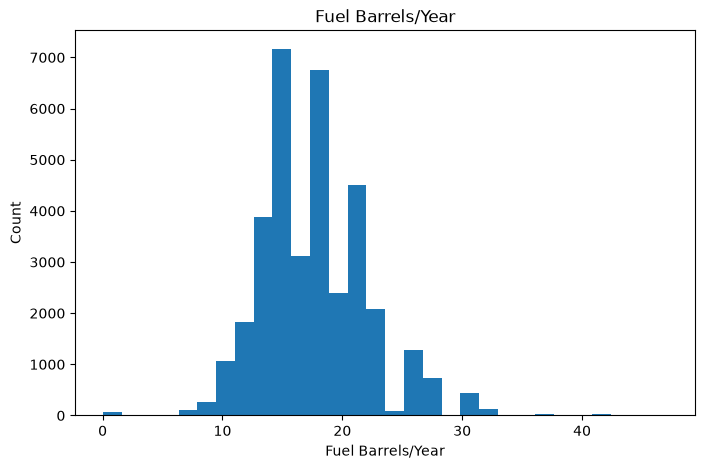

In [15]:
# your code here
fuel_barrels = vehicles["Fuel Barrels/Year"]

plt.figure(figsize=(8, 5))
plt.hist(fuel_barrels, bins=30)
plt.title("Fuel Barrels/Year")
plt.xlabel("Fuel Barrels/Year")
plt.ylabel("Count")
plt.show()


In [16]:
# your code here
print(fuel_barrels.describe())
print("Skewness:", fuel_barrels.skew())


count    35952.000000
mean        17.609056
std          4.467283
min          0.060000
25%         14.699423
50%         17.347895
75%         20.600625
max         47.087143
Name: Fuel Barrels/Year, dtype: float64
Skewness: 0.6382712089398944


2. CO2 Emission Grams/Mile 

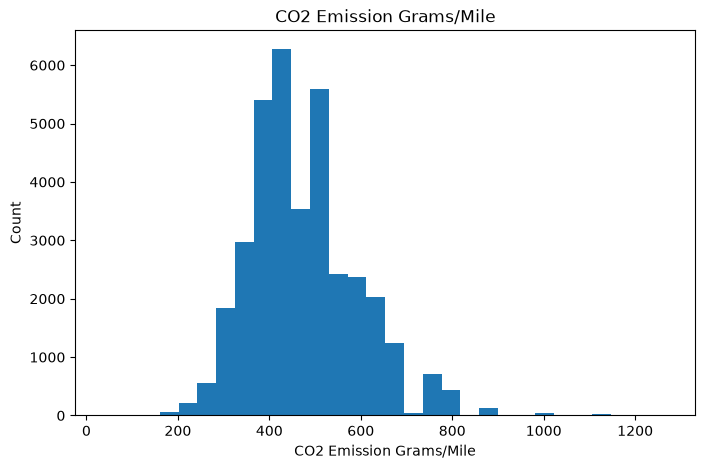

In [17]:
# your code here
co2 = vehicles["CO2 Emission Grams/Mile"]

plt.figure(figsize=(8, 5))
plt.hist(co2, bins=30)
plt.title("CO2 Emission Grams/Mile")
plt.xlabel("CO2 Emission Grams/Mile")
plt.ylabel("Count")
plt.show()


In [18]:
# your code here
print(co2.describe())

count    35952.000000
mean       475.316339
std        119.060773
min         37.000000
25%        395.000000
50%        467.736842
75%        555.437500
max       1269.571429
Name: CO2 Emission Grams/Mile, dtype: float64


In [19]:
print("Skewness:", co2.skew())


Skewness: 0.7416918391899279


3. Combined MPG

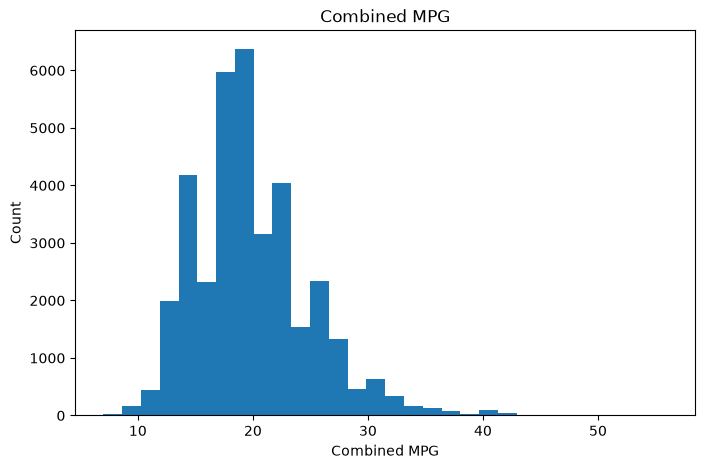

In [20]:
# your code here
combined_mpg = vehicles["Combined MPG"]

plt.figure(figsize=(8, 5))
plt.hist(combined_mpg, bins=30)
plt.title("Combined MPG")
plt.xlabel("Combined MPG")
plt.ylabel("Count")
plt.show()


In [21]:
# your code here
print(combined_mpg.describe())
print("Skewness:", combined_mpg.skew())


count    35952.000000
mean        19.929322
std          5.112409
min          7.000000
25%         16.000000
50%         19.000000
75%         23.000000
max         56.000000
Name: Combined MPG, dtype: float64
Skewness: 1.067772701547105


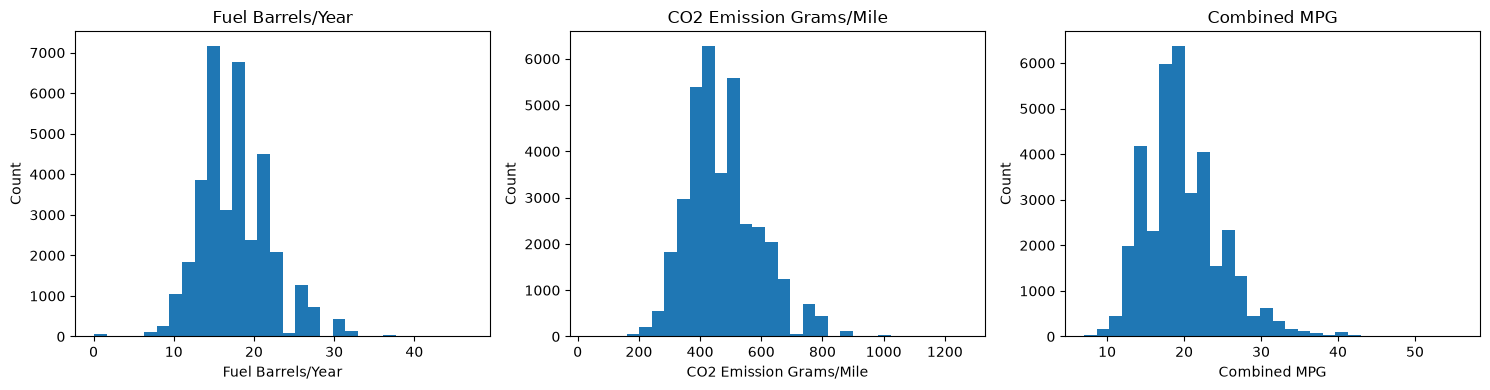

In [22]:
# your code here
# A compact side-by-side comparison makes the shapes easier to assess.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, series, title in zip(axes, [fuel_barrels, co2, combined_mpg],
                             ["Fuel Barrels/Year", "CO2 Emission Grams/Mile", "Combined MPG"]):
    ax.hist(series, bins=30)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


Which one(s) of the variables are nearly normally distributed? How do you know?

In [23]:
# your code here
from scipy.stats import skew

summary = pd.DataFrame({
    "mean": [fuel_barrels.mean(), co2.mean(), combined_mpg.mean()],
    "std": [fuel_barrels.std(), co2.std(), combined_mpg.std()],
    "skewness": [skew(fuel_barrels), skew(co2), skew(combined_mpg)]
}, index=["Fuel Barrels/Year", "CO2 Emission Grams/Mile", "Combined MPG"])
summary


,mean,std,skewness
Fuel Barrels/Year,17.609056,4.467283,0.638245
CO2 Emission Grams/Mile,475.316339,119.060773,0.741661
Combined MPG,19.929322,5.112409,1.067728


In [24]:
# your code here
# For a symmetric normal distribution, skewness is close to 0.
# The first two variables are less skewed than Combined MPG.
summary.sort_values("skewness")


,mean,std,skewness
Fuel Barrels/Year,17.609056,4.467283,0.638245
CO2 Emission Grams/Mile,475.316339,119.060773,0.741661
Combined MPG,19.929322,5.112409,1.067728


In [25]:
# your code here
# Visual inspection is important here because the dataset is very large;
# a formal normality test would reject even small departures from normality.
for variable, value in summary["skewness"].items():
    print(f"{variable}: skewness = {value:.3f}")


Fuel Barrels/Year: skewness = 0.638
CO2 Emission Grams/Mile: skewness = 0.742
Combined MPG: skewness = 1.068


In [ ]:
# your code here
# Based on the histograms and skewness, Fuel Barrels/Year and CO2 Emission
# Grams/Mile are the closest to approximately normal among the three.
# Combined MPG is clearly more right-skewed and therefore less nearly normal.


Fuel Barrels/Year and CO2 Emission Grams/Mile are the closest to approximately normal because their histograms are more bell-shaped and their skewness values (about 0.64 and 0.74) are lower than that of Combined MPG (about 1.07). However, none of the three variables is perfectly normal: all three have some positive (right) skew. With 35,952 observations, a formal normality test would be extremely sensitive to even small departures from normality, so the histogram and skewness are more useful for this lab.

None of them are normally ditributed. 

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

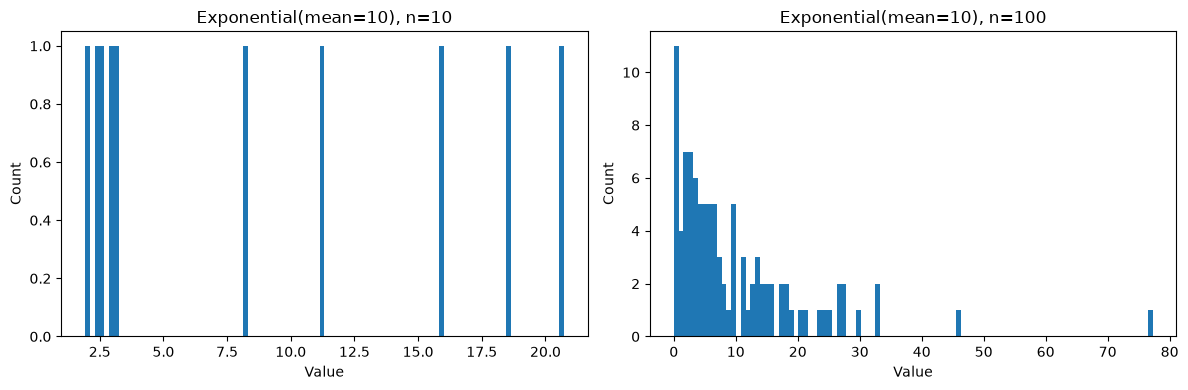

In [26]:
# your code here
def generate_exponential(mean, size):
    """Generate exponentially distributed random values with the given mean."""
    if mean <= 0:
        raise ValueError("mean must be greater than 0")
    if size < 0 or int(size) != size:
        raise ValueError("size must be a non-negative integer")
    return np.random.exponential(scale=mean, size=int(size))

exp_10 = generate_exponential(10, 10)
exp_100 = generate_exponential(10, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(exp_10, bins=100)
axes[0].set_title("Exponential(mean=10), n=10")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")
axes[1].hist(exp_100, bins=100)
axes[1].set_title("Exponential(mean=10), n=100")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


Both samples come from the same exponential distribution with mean 10, so their underlying shape is the same: many small values and fewer large values. The sample of 10 is much more irregular because it contains very few observations. The sample of 100 gives a clearer approximation of the expected right-skewed exponential shape. With 100 bins, many bins are empty because the samples are small relative to the number of bins.

How are the two distributions different?

The mean changes, so the distribution changes as well. 

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

In [27]:
# your code here
from scipy.stats import expon

mean = 10
prob_less_15 = expon.cdf(15, scale=mean)
prob_more_15 = 1 - prob_less_15

print(f"P(X < 15) = {prob_less_15:.6f} ({prob_less_15:.2%})")
print(f"P(X > 15) = {prob_more_15:.6f} ({prob_more_15:.2%})")


P(X < 15) = 0.776870 (77.69%)
P(X > 15) = 0.223130 (22.31%)


In [28]:
# your answer here
# Hint: This is same as saying P(x<15)
prob_less_15

np.float64(0.7768698398515702)

For an exponential distribution with mean 10 minutes, the rate is λ = 1/10.
P(X < 15) = 1 - e^(-λ·15) = 1 - e^(-1.5) ≈ 0.77687.
Therefore, there is approximately a 77.69% probability that a customer spends less than 15 minutes in the bank.

What is the probability that the customer will spend more than 15 minutes

In [29]:
# your code here
prob_more_15 = expon.sf(15, scale=10)
print(f"P(X > 15) = {prob_more_15:.6f} ({prob_more_15:.2%})")


P(X > 15) = 0.223130 (22.31%)
